# 06 · Market selection

**Question:** which states should receive the campaign? Can we pick a set that measures better than a random one?

**Answer:** exclusion rules and **stratified randomization** help: same noise as random draws, but the budget share narrows from **8–19%** to **12–16%** of traffic. Searching 2,000 sets for the best historical fit finds sets ~4× better *in history*, but they are **no better out-of-sample** (correlation **−0.01**).

**Method:** selection uses history only (before 2021-01-04).
- **Backtest RMSE:** zero-lift DiD error on 23 overlapping 21-day before/after windows inside history
- **Out-of-sample error:** zero-lift DiD error in the real January window (12/07–01/03 vs 01/04–01/31), never used for selection

**Data:** GA4 Google Merchandise Store public sample, sessions per US state per day.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/ga4_state_daily.csv", parse_dates=["date"])
START = pd.Timestamp("2021-01-04")

wide = df.pivot(index="date", columns="state", values="sessions").fillna(0).astype(float)
hist = wide[wide.index < START]
size = hist.mean()                                 # avg sessions/day, all 51 states
share = size / size.sum()                          # share of national traffic

def did_lift(data, treated, before, after):
    T = data[treated].sum(axis=1); C = data.drop(columns=treated).sum(axis=1)
    return (T[after].sum() / T[before].sum()) / (C[after].sum() / C[before].sum()) - 1

def backtest_rmse(data, treated, L=21):
    """Zero-lift DiD error on every L-day before/after window inside history."""
    h = data[data.index < START]
    errors = []
    for end in range(2 * L, len(h) + 1):
        idx = np.arange(len(h))
        before = (idx >= end - 2 * L) & (idx < end - L)
        after  = (idx >= end - L) & (idx < end)
        errors.append(did_lift(h, treated, before, after))
    return np.sqrt(np.mean(np.square(errors)))

def jan_error(data, treated):
    """Zero-lift DiD error in the real January window (12/07–01/03 vs 01/04–01/31). Never used for selection."""
    before = (data.index >= START - pd.Timedelta(days=28)) & (data.index < START)
    after  = (data.index >= START) & (data.index < START + pd.Timedelta(days=28))
    return abs(did_lift(data, treated, before, after))

share.sort_values(ascending=False).head(8).round(3)

state
California       0.214
Texas            0.075
New York         0.069
Virginia         0.066
Florida          0.047
Massachusetts    0.040
Illinois         0.038
Pennsylvania     0.031
dtype: float64

## Step 1 · Exclusion rules

| Rule | Why |
|---|---|
| **Too small**: median < 10 sessions/day | Small states are ~4.5× noisier (median placebo error 11.3% vs 2.5%, see [02](02_difference_in_differences.ipynb)) |
| **Too big**: > 15% of national traffic | Expensive, removes the largest control, and no mix of other states resembles it (weight 0 in [03](03_synthetic_control.ipynb)); kept as a **control** only |

In [2]:
daily_median = df.groupby("state").sessions.median()

too_small = daily_median[daily_median < 10].index.tolist()
too_big   = share[share > 0.15].index.tolist()

data = wide[daily_median[daily_median >= 10].index]   # drop tiny states entirely (too noisy even as controls)
CANDIDATES = [s for s in data.columns if s not in too_big]
print(f"Too small: {len(too_small)} states | Too big: {too_big}")
print(f"Candidates for treatment: {len(CANDIDATES)}")

Too small: 17 states | Too big: ['California']
Candidates for treatment: 33


## Step 2 · Random vs stratified randomization

Stratified: sort candidates by size, split into 6 strata, pick one state per stratum. Compared over 1,000 draws each on budget share (treated share of traffic) and backtest RMSE.

In [3]:
rng = np.random.default_rng(0)
strata = np.array_split(size[CANDIDATES].sort_values().index.values, 6)

def draw_random():
    return list(rng.choice(CANDIDATES, 6, replace=False))

def draw_stratified():
    return [rng.choice(s) for s in strata]     # one state per size stratum

rows = []
for method, draw in [("random", draw_random), ("stratified", draw_stratified)]:
    for _ in range(1000):
        t = draw()
        rows.append({"method": method, "budget_share": share[t].sum(), "backtest_rmse": backtest_rmse(data, t)})
B = pd.DataFrame(rows)
B.groupby("method").agg(share_p10=("budget_share", lambda x: x.quantile(.1)),
                        share_p90=("budget_share", lambda x: x.quantile(.9)),
                        median_rmse=("backtest_rmse", "median")).round(3)

,share_p10,share_p90,median_rmse
method,,,
random,0.082,0.193,0.023
stratified,0.122,0.160,0.023


## Step 3 · Search 2,000 random sets for the lowest backtest RMSE

In [4]:
rng = np.random.default_rng(1)
search = []
for _ in range(2000):
    t = list(rng.choice(CANDIDATES, 6, replace=False))
    search.append({"set": ", ".join(sorted(t)), "treated": t,
                   "backtest_rmse": backtest_rmse(data, t), "budget_share": share[t].sum()})
S = pd.DataFrame(search)
S.nsmallest(10, "backtest_rmse")[["set", "backtest_rmse", "budget_share"]].round(4)

,set,backtest_rmse,budget_share
1494,"Massachusetts, Nebraska, Ohio, Oregon, Texas, ...",0.0052,0.2246
1051,"Florida, Maryland, Massachusetts, Michigan, Ut...",0.0059,0.2023
935,"Florida, Massachusetts, Nebraska, Tennessee, T...",0.0059,0.2493
1760,"Arizona, Missouri, New Jersey, New York, Penns...",0.0062,0.2242
637,"Alabama, Connecticut, Kansas, New Jersey, Tenn...",0.0069,0.1013
1741,"Connecticut, Iowa, Michigan, Nebraska, New Yor...",0.0070,0.1474
811,"New York, North Carolina, Pennsylvania, Tennes...",0.0070,0.1832
1937,"Arizona, Colorado, Indiana, Massachusetts, Nor...",0.0070,0.1845
1914,"Iowa, Kentucky, Louisiana, New York, Pennsylva...",0.0071,0.1364
359,"Indiana, Massachusetts, Tennessee, Texas, Virg...",0.0073,0.2389


## Step 4 · Out-of-sample check: do the best historical sets stay best in January?

            backtest_rmse  jan_error
rank_group                          
best 20%           0.0132     0.0131
2nd                0.0182     0.0127
3rd                0.0227     0.0157
4th                0.0279     0.0120
worst 20%          0.0357     0.0125

Correlation(backtest RMSE, January error): -0.01


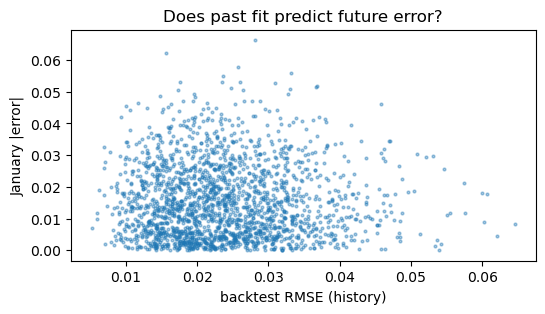

In [5]:
S["jan_error"] = [jan_error(data, t) for t in S.treated]

S["rank_group"] = pd.qcut(S.backtest_rmse, 5, labels=["best 20%", "2nd", "3rd", "4th", "worst 20%"])
print(S.groupby("rank_group", observed=True)[["backtest_rmse", "jan_error"]].median().round(4))
print(f"\nCorrelation(backtest RMSE, January error): {S.backtest_rmse.corr(S.jan_error):.2f}")

plt.figure(figsize=(6, 3))
plt.scatter(S.backtest_rmse, S.jan_error, s=4, alpha=0.4)
plt.xlabel("backtest RMSE (history)"); plt.ylabel("January |error|"); plt.title("Does past fit predict future error?"); plt.show()

## Findings

**Exclusions:** 17 states too small; California (21% of traffic) control-only → 33 treatment candidates.

**Random vs stratified (1,000 draws each)**

| Method | Budget share (p10 – p90) | Median backtest RMSE |
|---|---|---|
| Random | 8.2% – 19.3% | 2.3% |
| **Stratified** | **12.2% – 16.0%** | 2.3% |

- Same noise, much more predictable cost, and every draw mixes small and large states.

**Search (2,000 sets)**
- Top 10 sets: backtest RMSE **0.5% – 0.7%** vs a median of 2.3%, about 4× better *in history*
- Frequent picks: Massachusetts, Virginia, Tennessee (5 of 10); Texas, New York, Pennsylvania (4 of 10), mostly mid/large states
- Budget share of the top 10 ranges **10% – 25%** at similar error, so the lowest-error set isn't the cheapest

**Out-of-sample (January)**

| Group by backtest RMSE | Backtest RMSE | January error |
|---|---|---|
| Best 20% | 1.3% | 1.3% |
| 2nd | 1.8% | 1.3% |
| 3rd | 2.3% | 1.6% |
| 4th | 2.8% | 1.2% |
| Worst 20% | 3.6% | 1.3% |

- **Correlation = −0.01.** Picking the best of 2,000 noisy tries selects lucky sets (winner's curse), and the history (64 holiday days) is a different regime from January.

## Recommended procedure

1. **Exclude** geos too small to measure; keep geos too large to treat as controls.
2. **Stratify** treatment selection by size (or region, or other key traits).
3. **Check power** for the chosen design (MDE < expected effect) → [05](05_power_analysis_mde.ipynb).
4. **Search only with long, representative history**, and validate any ranking on a held-out period.
5. **Report the budget share** and avoid seasonal transitions such as Q4.